# Analyse BlueSeis BSPF Events

In [9]:
import os
import obspy as obs
import matplotlib.pyplot as plt
import numpy as np

from obspy.clients.fdsn import Client
from obspy.geodetics.base import gps2dist_azimuth

In [10]:
from functions.makeplot_waveform_comparison_all import __makeplot_waveform_comparison_all
from functions.makeplot_spectra_comparison_fill import __makeplot_spectra_comparison_fill
from functions.makeplot_waveform_comparison_cc import __makeplot_waveform_comparison_cc
from functions.compute_cwt import __compute_cwt
from functions.compute_backazimuth import __compute_backazimuth
from functions.get_theoretical_backazimuth import __get_theoretical_backazimuth
from functions.compute_backazimuth_tangent import __compute_backazimuth_tangent
from functions.compare_backazimuth_codes import __compare_backazimuth_codes
from functions.makeplot_cwt_all import __makeplot_cwt_all
from functions.compute_velocity_from_amplitude_ratio import __compute_velocity_from_amplitude_ratio
from functions.makeplot_velocities import __makeplot_velocities

## Configurations

In [11]:
config = {}

# BSPF coordinates
config['BSPF_lon'] = -116.455439
config['BSPF_lat'] = 33.610643

# specify event
config['name'] = "M41"
config['tbeg'] = obs.UTCDateTime("2022-12-31 12:12:20")
config['tend'] = obs.UTCDateTime("2022-12-31 12:12:55")

# specify path for figures
config['path_to_figs'] = "./figures/"

# specify path to data
config['path_to_data'] = "./data/"


## Load Data

In [12]:
event = Client("USGS").get_events(starttime=config['tbeg'], endtime=config['tend'], minmagnitude=4.0)
event = event[0]

# Eventtime
config['eventtime'] = event.origins[0].time

dist, az, baz = gps2dist_azimuth(event.origins[0].latitude, event.origins[0].longitude,
                                 config['BSPF_lat'], config['BSPF_lon'],
                                 )
dist/1000, az, baz

/tmp/ipykernel_305416/63862153.py:7: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  dist, az, baz = gps2dist_azimuth(event.origins[0].latitude, event.origins[0].longitude,


(24.334569833387384, 346.2992112316263, 166.2649290568653)

## Load Waveforms

In [13]:
st0 = obs.read(config['path_to_data']+"eventM41_6c.mseed")

st0.trim(st0[0].stats.starttime+5, st0[0].stats.endtime)

15 Trace(s) in Stream:
II.PFO.10.BHE  | 2022-12-31T12:12:24.994538Z - 2022-12-31T12:12:54.994538Z | 40.0 Hz, 1201 samples
II.PFO.10.BHN  | 2022-12-31T12:12:24.994538Z - 2022-12-31T12:12:54.994538Z | 40.0 Hz, 1201 samples
II.PFO.10.BHZ  | 2022-12-31T12:12:24.994538Z - 2022-12-31T12:12:54.994538Z | 40.0 Hz, 1201 samples
II.RPFO.al.BJE | 2022-12-31T12:12:24.996349Z - 2022-12-31T12:12:54.996349Z | 40.0 Hz, 1201 samples
II.RPFO.al.BJN | 2022-12-31T12:12:24.996349Z - 2022-12-31T12:12:54.996349Z | 40.0 Hz, 1201 samples
II.RPFO.al.BJZ | 2022-12-31T12:12:24.996349Z - 2022-12-31T12:12:54.996349Z | 40.0 Hz, 1201 samples
II.RPFO.in.BJE | 2022-12-31T12:12:24.995468Z - 2022-12-31T12:12:54.995468Z | 40.0 Hz, 1201 samples
II.RPFO.in.BJN | 2022-12-31T12:12:24.995468Z - 2022-12-31T12:12:54.995468Z | 40.0 Hz, 1201 samples
II.RPFO.in.BJZ | 2022-12-31T12:12:24.995468Z - 2022-12-31T12:12:54.995468Z | 40.0 Hz, 1201 samples
II.RPFO.mi.BJE | 2022-12-31T12:12:24.996005Z - 2022-12-31T12:12:54.996005Z | 40.0 Hz, 

In [14]:
submask = "mi"

bspf0 = st0.select(station="BSPF").copy()
pfo0 = st0.select(station="PFO*").copy()
adr0 = st0.select(station="RPFO", location=submask[:2]).copy()

if submask == "in":
    config['fmin'], config['fmax'] = 1.0, 5.0
elif submask == "mi":
    config['fmin'], config['fmax'] = 0.5, 1.0
elif submask == "al":
    config['fmin'], config['fmax'] = 0.1, 0.5

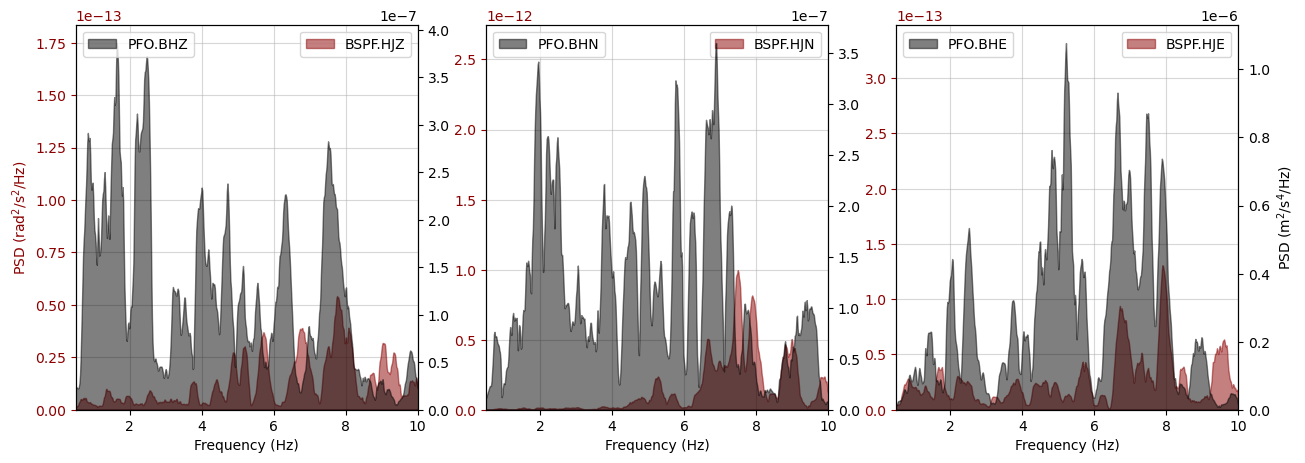

In [15]:
acc = st0.select(station="PFO*").copy()
rot = st0.select(station="BSPF").copy()

rot = rot.detrend("simple")
acc = acc.detrend("simple")

fig = __makeplot_spectra_comparison_fill(rot, acc, fmin=0.5, fmax=10, ylog=False, xlog=False, fill=True)

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_spectra_all.png", format="png", dpi=150, bbox_inches='tight');


### Plot Waveforms

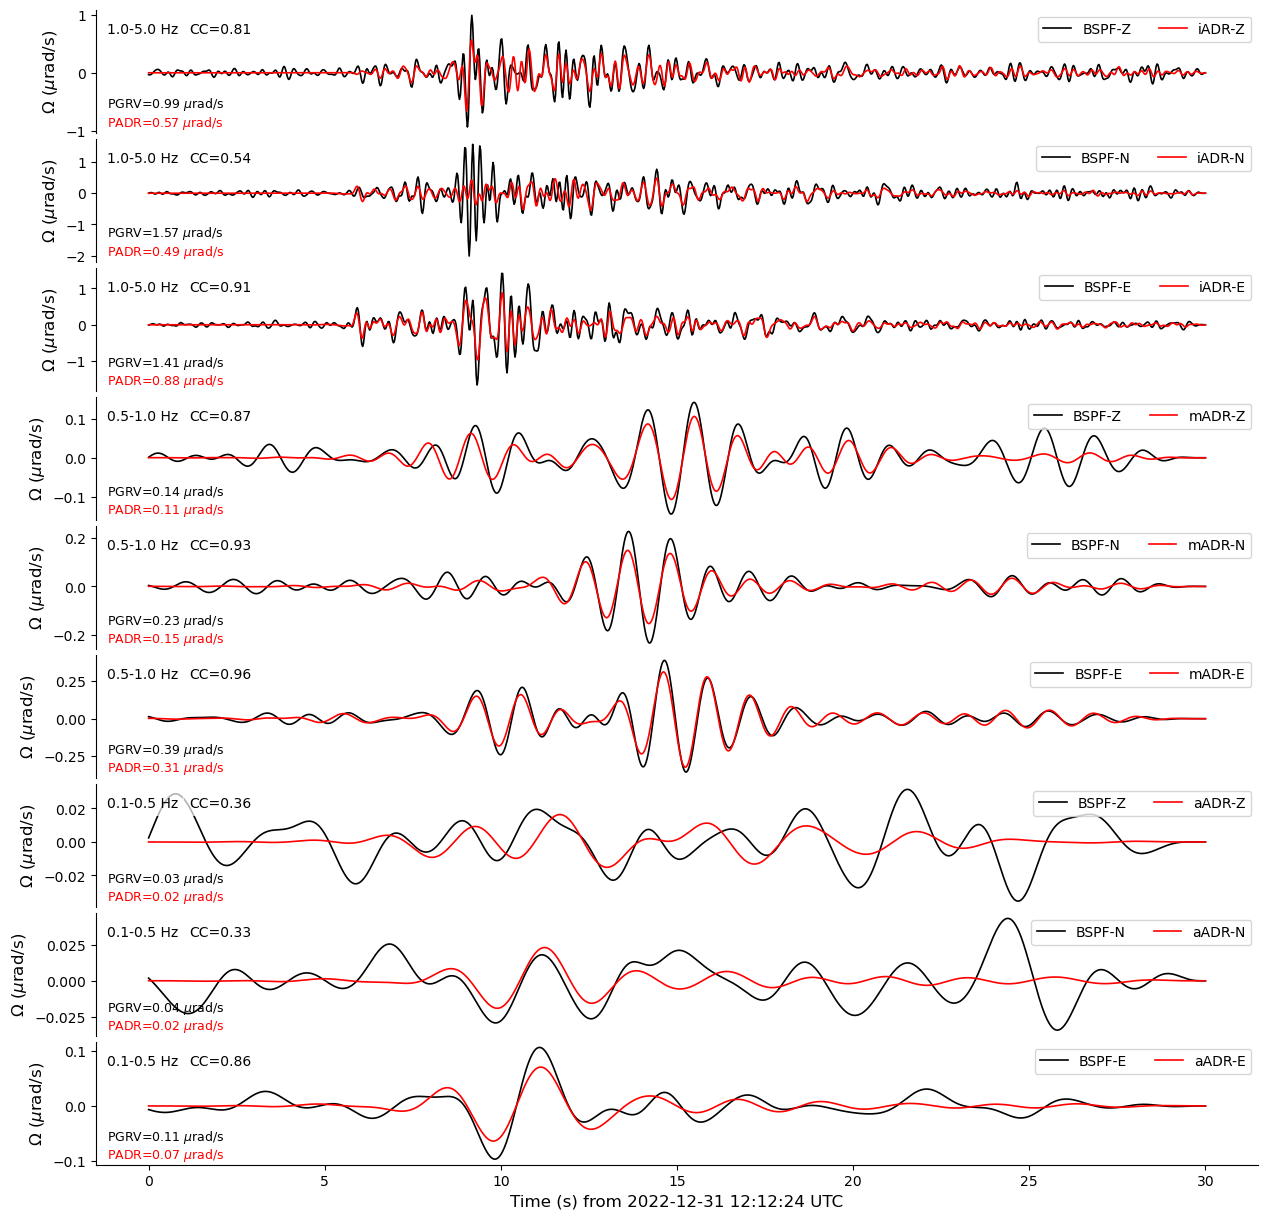

In [16]:
fig = __makeplot_waveform_comparison_all(st0);

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_waveforms_all.png", format="png", dpi=150, bbox_inches='tight');


In [17]:
def __makeplot_waveform_comparison(st_in):

    from obspy.signal.cross_correlation import correlate
    import numpy as np
    import matplotlib.pyplot as plt

    st = st_in.copy()

    # st = st.trim(st[0].stats.starttime+5, st[0].stats.endtime-15).copy()

    fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    lw = 1.2

    font = 16

    fbands = {"in":(1.0, 5.0), "mi":(0.5, 1.0), "al":(0.1, 0.5)}

    offset = [0, 0, 0]

    plt.subplots_adjust(hspace=0.05)

    scaling, unit = 1e6, f"$\mu$rad/s"

    idx = 0
    for _m, array in enumerate(["mi"]):

        fband = fbands[array]

        _adr = st.select(location=array).copy()
        _bspf = st.select(station="BSPF").copy()

        _bspf = _bspf.detrend("simple").taper(0.01).filter("bandpass", freqmin=fband[0], freqmax=fband[1], corners=4, zerophase=True)
        _adr = _adr.detrend("simple").taper(0.01).filter("bandpass", freqmin=fband[0], freqmax=fband[1], corners=4, zerophase=True)

        for _k, comp in enumerate(["Z", "N", "E"]):

            ax[idx].plot(_bspf.select(channel=f"*{comp}")[0].times(), _bspf.select(channel=f"*{comp}")[0].data*scaling, label=f"BSPF-{comp}", color="k", lw=lw)
            ax[idx].plot(_adr.select(channel=f"*{comp}")[0].times(), _adr.select(channel=f"*{comp}")[0].data*scaling, label=f"{array[0]}ADR-{comp}", color="r", lw=lw)

            cc = round(correlate(_bspf.select(channel=f"*{comp}")[0].data, _adr.select(channel=f"*{comp}")[0].data, 0, demean=True, normalize='naive', method='auto')[0], 2)

            # rmse = np.round( np.sqrt( np.mean( ( ( _adr.select(channel=f"*{comp}")[0].data - _bspf.select(channel=f"*{comp}")[0].data )*scaling )**2 ) ), 3)

            ## pick peak rotation velocity
            pgrv = round(np.amax(_bspf.select(channel=f"*{comp}")[0].data*scaling), 2)

            ## pick peak adr
            padr = round(np.amax(_adr.select(channel=f"*{comp}")[0].data*scaling), 2)


            t1 = ax[idx].text(0.01, 0.9, f"{fband[0]}-{fband[1]} Hz", ha='left', va='top', transform=ax[idx].transAxes, fontsize=font-2)
            t1.set_bbox(dict(facecolor='white', alpha=0.7, linewidth=0))
            t2 = ax[idx].text(0.15, 0.9, f"CC={cc}", ha='left', va='top', transform=ax[idx].transAxes, fontsize=font-2)
            t2.set_bbox(dict(facecolor='white', alpha=0.7, linewidth=0))
            t3 = ax[idx].text(0.01, 0.30, f"PGRV={pgrv} {unit}", ha='left', va='top', transform=ax[idx].transAxes, fontsize=font-3)
            t3.set_bbox(dict(facecolor='white', alpha=0., linewidth=0))
            t4 = ax[idx].text(0.01, 0.15, f"PADR={padr} {unit}", ha='left', color="r", va='top', transform=ax[idx].transAxes, fontsize=font-3)
            t4.set_bbox(dict(facecolor='white', alpha=0., linewidth=0))

            ax[idx].legend(loc=1, ncols=4, fontsize=font-2)

            # ax[idx].grid(which="both", alpha=0.5)

            ax[idx].set_ylabel(f"$\Omega$ ({unit})", fontsize=font)
            ax[idx].xaxis.label.set_size(font-1)
            ax[idx].yaxis.label.set_size(font-1)

            if idx < 8:
                ax[idx].tick_params(axis='x', bottom=False)

            for pos in ["right", "top", "bottom"]:
                ax[idx].spines[pos].set_visible(False)

            idx += 1

    ax[idx-1].spines["bottom"].set_visible(True)

    ax[idx-1].set_xlabel(f"Time (s) from {st_in[0].stats.starttime.date} {str(st_in[0].stats.starttime.time).split('.')[0]} UTC", fontsize=font)

    # ax[0].set_title(f"{config['tbeg'].date} | {config['fmin']}-{config['fmax']} Hz | ADR {submask} | CC$_Z$ = {cc_Z} | CC$_N$ = {cc_N} | CC$_E$ = {cc_E}")

    plt.show();
    return fig

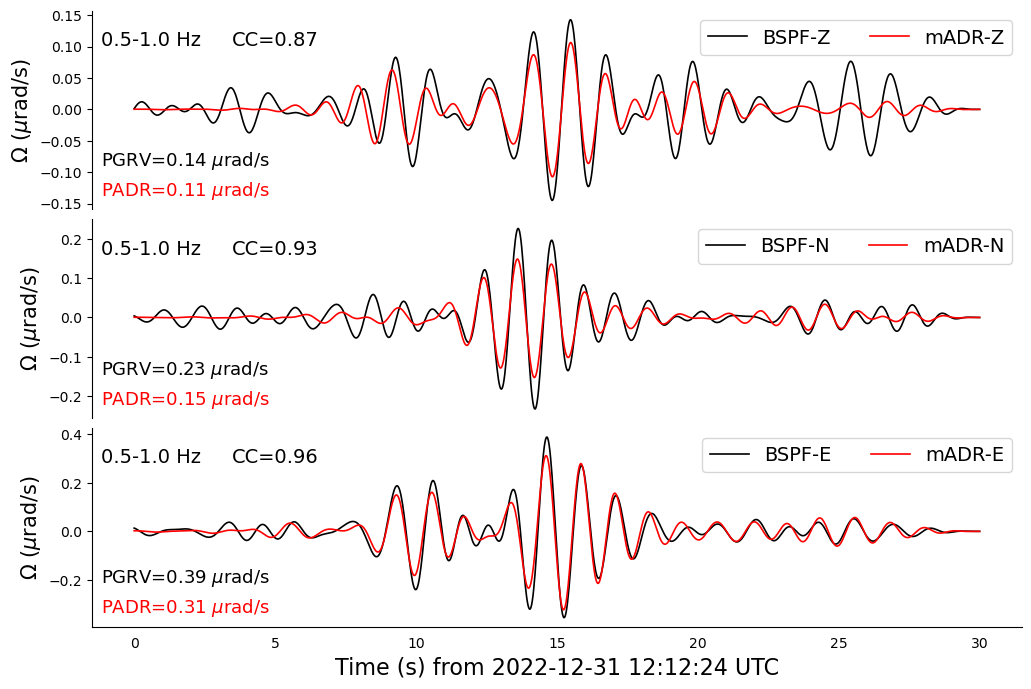

In [18]:
fig = __makeplot_waveform_comparison(st0);

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_waveforms_single.png", format="png", dpi=150, bbox_inches='tight');

### Specify Frequency Range

In [19]:
fmin, fmax = 0.5, 1.0

In [20]:
acc = st0.select(station="PFO*").copy()
rot = st0.select(station="BSPF").copy()

rot = rot.detrend("simple")
acc = acc.detrend("simple")

rot = rot.taper(0.01, type="cosine")
acc = acc.taper(0.01, type="cosine")

rot = rot.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)
acc = acc.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

### Compare BSPF and ADR

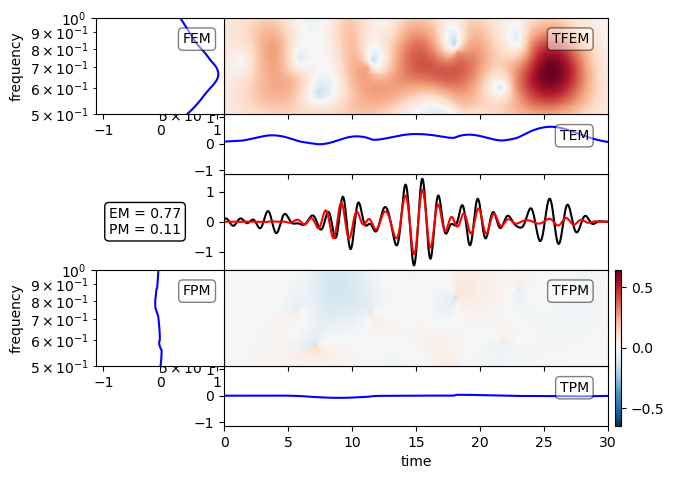

In [21]:
from scipy.signal import hilbert
from obspy.signal.tf_misfit import plot_tf_misfits

component = "Z"
array = "mi"

st1 = st0.copy()

st1 = st1.detrend("demean").taper(0.01, type="cosine")
st1 = st1.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

s1 = st1.select(station="BSPF", channel=f"*{component}")[0].data
s2 = st1.select(station="RPFO", location=array, channel=f"*{component}")[0].data

dt = st1[0].stats.delta

plot_tf_misfits(s1, s2, dt=dt, fmin=fmin, fmax=fmax, show=True, norm="global")


In [22]:
def __makeplotStream_cwt(st, fscale=None, fmin=0.1, fmax=20):

    from scipy import fftpack
    from andbro__fft import __fft
    from numpy import array, log10, logspace, linspace, meshgrid, abs
    from obspy.signal.tf_misfit import cwt
    from obspy.imaging.cm import obspy_sequential

    import matplotlib.pyplot as plt


    NN = len(st)

    rot_scaling, rot_unit = 1e6, r"$\mu$rad/s"
    trans_scaling, trans_unit = 1e3, r"mm/s$^2$"
    strain_scaling, strain_unit = 1, r"nm/m"

    fig, axes = plt.subplots(NN, 2, figsize=(12, 10), sharex='col')

    font = 10

    plt.subplots_adjust(hspace=0.25, wspace=0.15)

    ## _______________________________________________

    st.sort(keys=['channel'], reverse=True)


    for i, tr in enumerate(st):

        if tr.stats.channel[-2] == "J":
            scaling = rot_scaling
        elif tr.stats.channel[-2] == "H":
            scaling = trans_scaling
        elif tr.stats.channel[-2] == "S":
            scaling = strain_scaling

        t = linspace(0, tr.stats.delta * tr.stats.npts, tr.stats.npts)

        scalogram = cwt(tr.data, tr.stats.delta, 8, fmin, fmax)

        x, y = meshgrid(t, logspace(log10(fmin), log10(fmax), scalogram.shape[0]))

        ## _________________________________________________________________
        if tr.stats.channel[-2] == "J":
            axes[i,0].plot(
                        tr.times(),
                        tr.data*rot_scaling,
                        color='black',
                        label='{} {}'.format(tr.stats.station, tr.stats.channel),
                        lw=1.0,
                        )
            axes[i,1].pcolormesh(x, y, abs(scalogram), cmap=obspy_sequential)


        elif tr.stats.channel[-2] == "H":
            axes[i,0].plot(
                        tr.times(),
                        tr.data*trans_scaling,
                        color='darkblue',
                        label='{} {}'.format(tr.stats.station, tr.stats.channel),
                        lw=1.0,
                        )
            axes[i,1].pcolormesh(x, y, abs(scalogram), cmap=obspy_sequential)

        elif tr.stats.channel[-2] == "S":
            axes[i,0].plot(
                        tr.times(),
                        tr.data*strain_scaling,
                        color='darkred',
                        label='{} {}'.format(tr.stats.station, tr.stats.channel),
                        lw=1.0,
                        )
            axes[i,1].pcolormesh(x, y, abs(scalogram), cmap=obspy_sequential)



        axes[i,1].set_yscale("log")

        if tr.stats.channel[1] == "J":
            sym, unit = r"$\Omega$", rot_unit
        elif tr.stats.channel[1] == "H":
            sym, unit = "a", trans_unit
        elif tr.stats.channel[1] == "S":
            sym, unit = "$\epsilon$", strain_unit
        else:
            unit = "Amplitude", "a.u."

        axes[i,0].set_ylabel(f'{sym} ({unit})',fontsize=font)
        axes[i,1].set_ylabel(f'f (Hz)',fontsize=font)
        axes[i,0].legend(loc='upper right', framealpha=1.0, fontsize=font-2)

#         axes[i,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
#         axes[i,1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    axes[NN-1,0].set_xlabel(f"Time from {tr.stats.starttime.date} {str(tr.stats.starttime.time)[:8]} UTC (s)",fontsize=font)
    axes[NN-1,1].set_xlabel(f"Time from {tr.stats.starttime.date} {str(tr.stats.starttime.time)[:8]} UTC (s)",fontsize=font)

    return fig

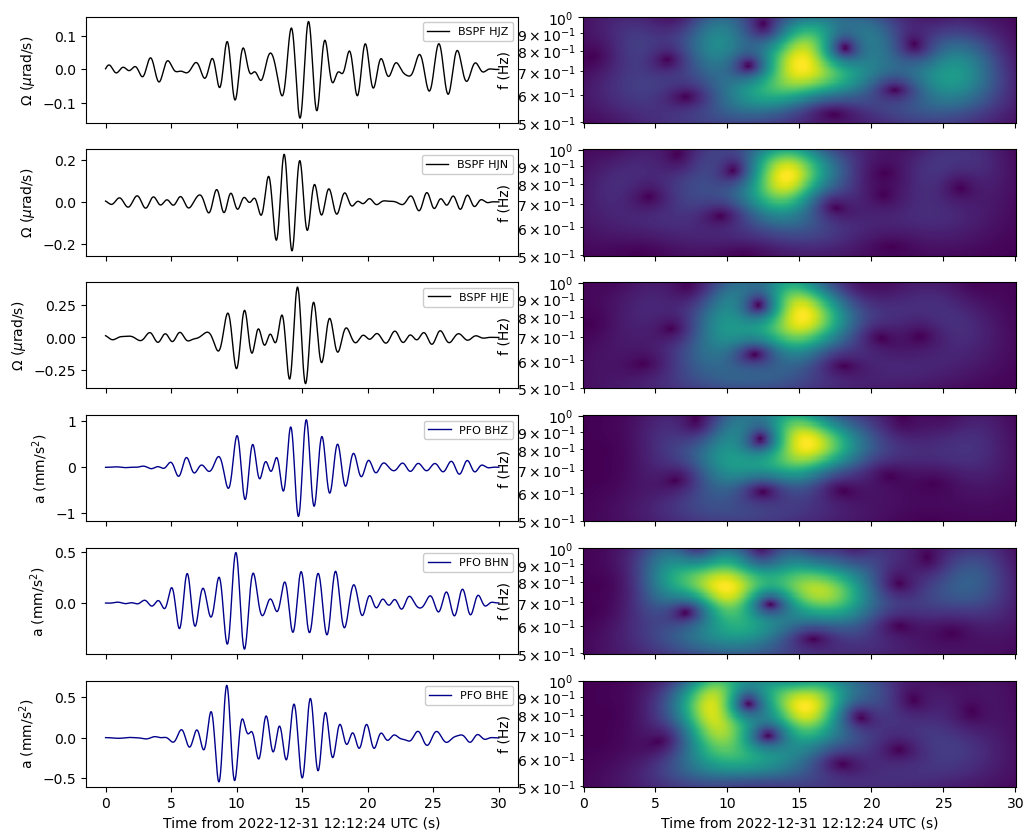

In [23]:
stall = rot.copy()
stall += acc.copy()

fig = __makeplotStream_cwt(stall, fmin=fmin, fmax=fmax);

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_strain_cwt.png", format="png", dpi=150, bbox_inches='tight');


### Waveform Comparision - Acceleration and Rotation Rate

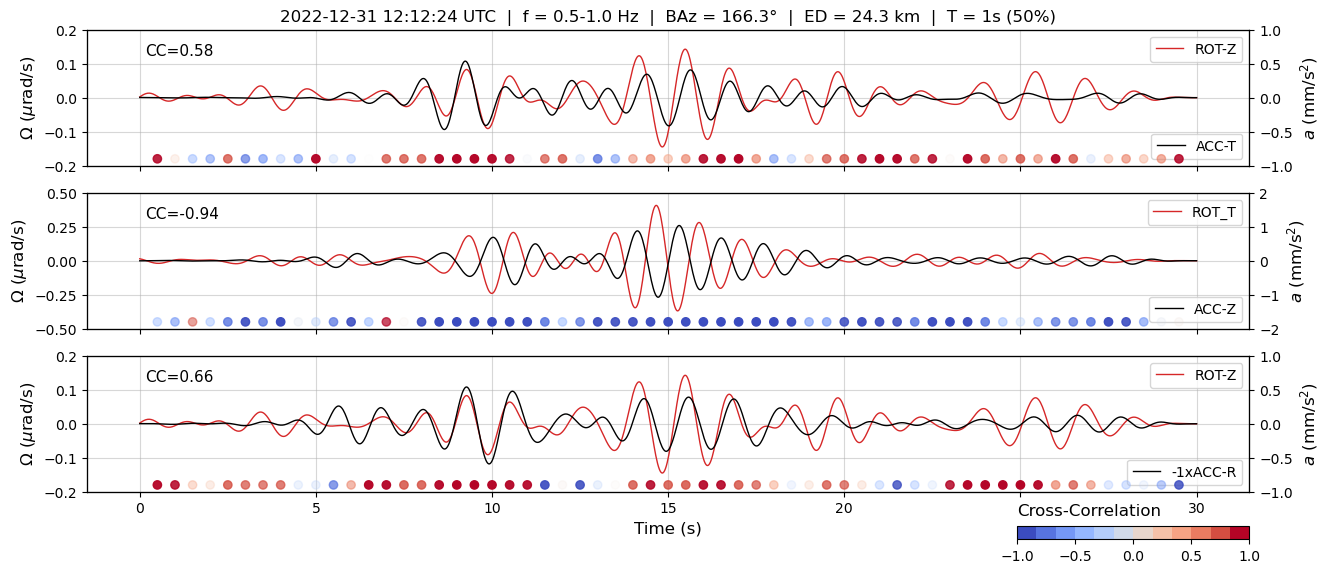

In [24]:
fig = __makeplot_waveform_comparison_cc(rot, acc, baz, fmin, fmax, dist, twin_sec=1, twin_overlap=0.5)

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_waveforms_cc.png", format="png", dpi=150, bbox_inches='tight');


### Plot Spectra of Acceleration and Rotation Rate

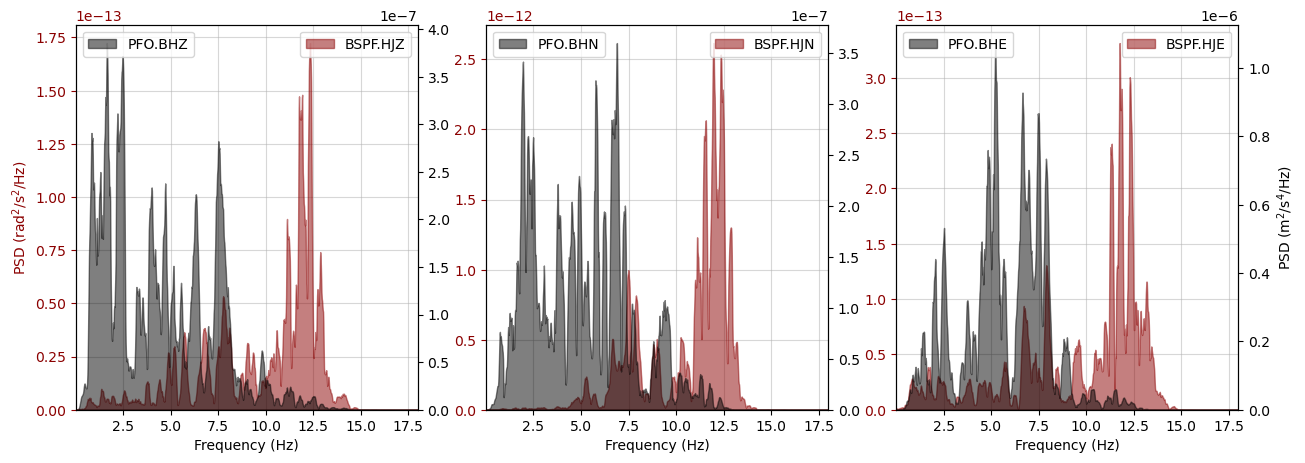

In [25]:
acc0 = st0.select(station="PFO*").copy()
rot0 = st0.select(station="BSPF").copy()

fig = __makeplot_spectra_comparison_fill(rot0, acc0, fmin=0.01, fmax=18, ylog=False, xlog=False, fill=True)

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_spectra_all_fill.png", format="png", dpi=150, bbox_inches='tight');


### Wavelet Comparsion

In [26]:
rot0 = st0.select(station="BSPF").copy()

rot0 = rot0.detrend("demean")

outs = {}
for component in ["E", "N", "Z"]:

    ttt = rot0[0].times()
    dt = rot0[0].stats.delta # seconds
    arr = rot0.select(channel=f"*{component}")[0].data

    out = __compute_cwt(ttt, arr, dt, tscale="sec",
                        datalabel=f"ROMY-{component}",
                        period=False,
                        ymax=15,
                        plot=False,
                       )
    # add to dict
    outs[component] = out

    # # store image
    # out['fig'].savefig(config['path_to_figs']+f"ROMY_{config['name']}_cwt_{component}.png",
    #                    format="png", dpi=150, bbox_inches='tight');


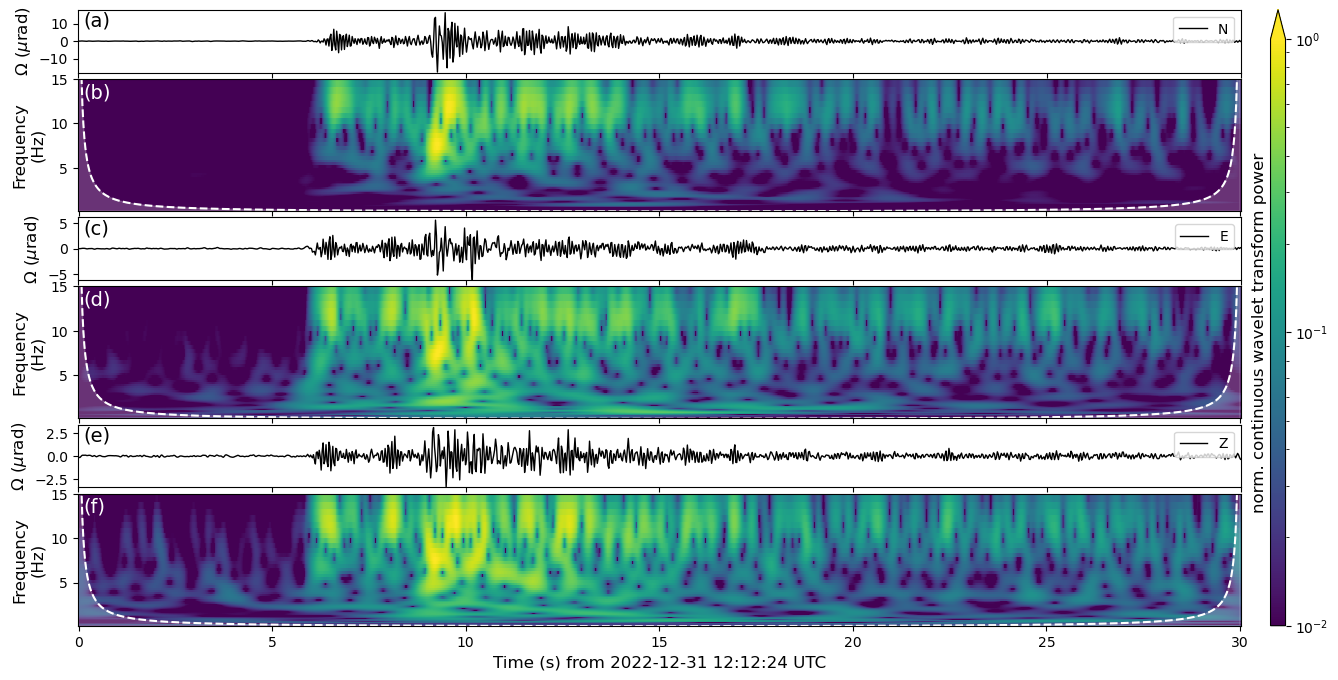

In [27]:
fig = __makeplot_cwt_all(rot0, outs, clog=True, ylim=15)

# fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_cwt_all.png", format="png", dpi=150, bbox_inches='tight');


### Backazimuth Estimate

In [28]:
config['station_longitude'] = config['BSPF_lon']
config['station_latitude'] = config['BSPF_lat']

## specify window length for baz estimation in seconds
config['win_length_sec'] = 1/fmin

## define an overlap for the windows in percent (50 -> 50%)
config['overlap'] = 75

## specify steps for degrees of baz
config['step'] = 1

# specify event data
config['event'] = event

# get expected event info
baz, az, dist = __get_theoretical_backazimuth(config['BSPF_lat'], config['BSPF_lon'], event_obj=event, fdsn_client='USGS')


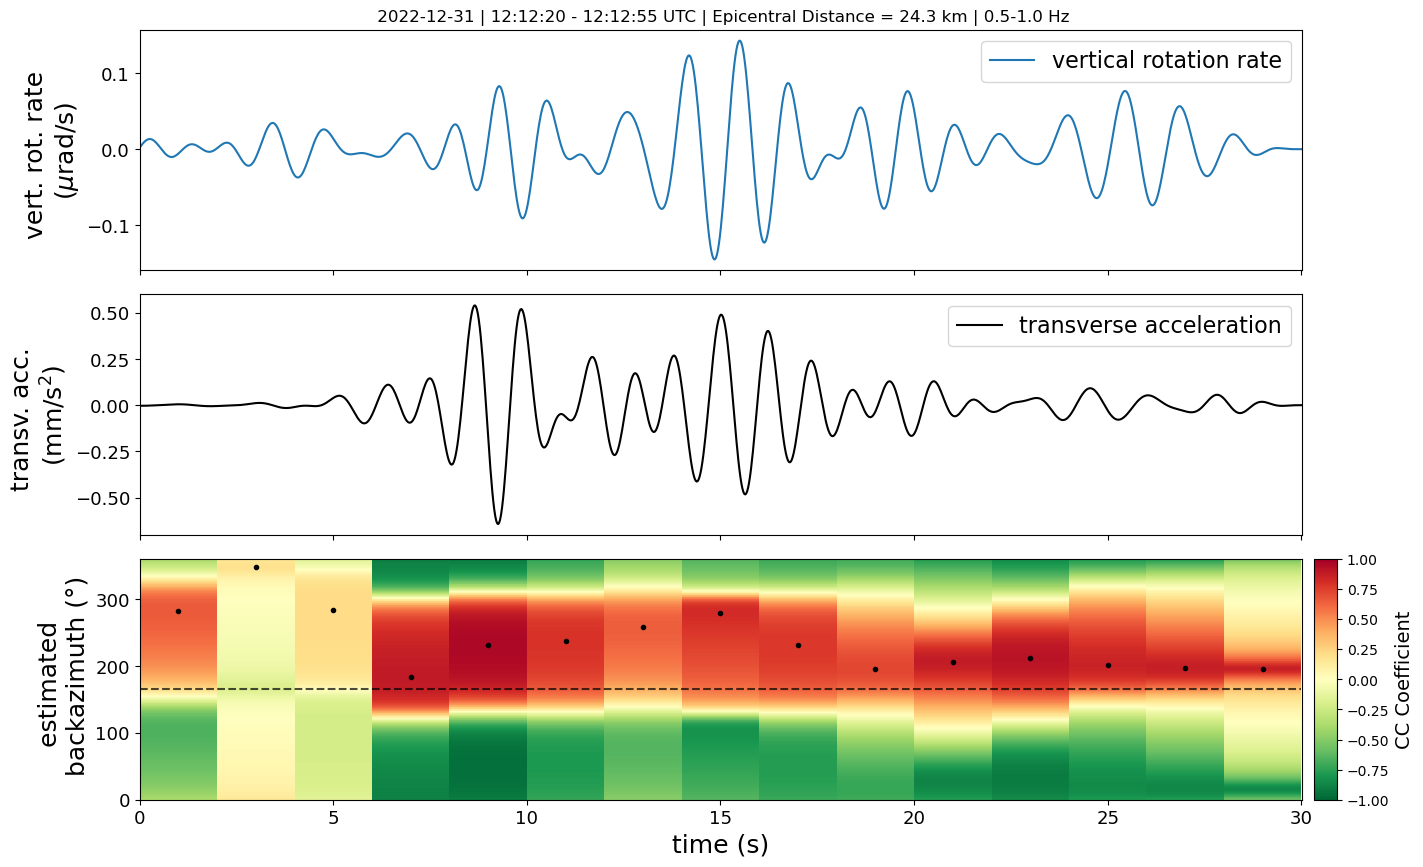

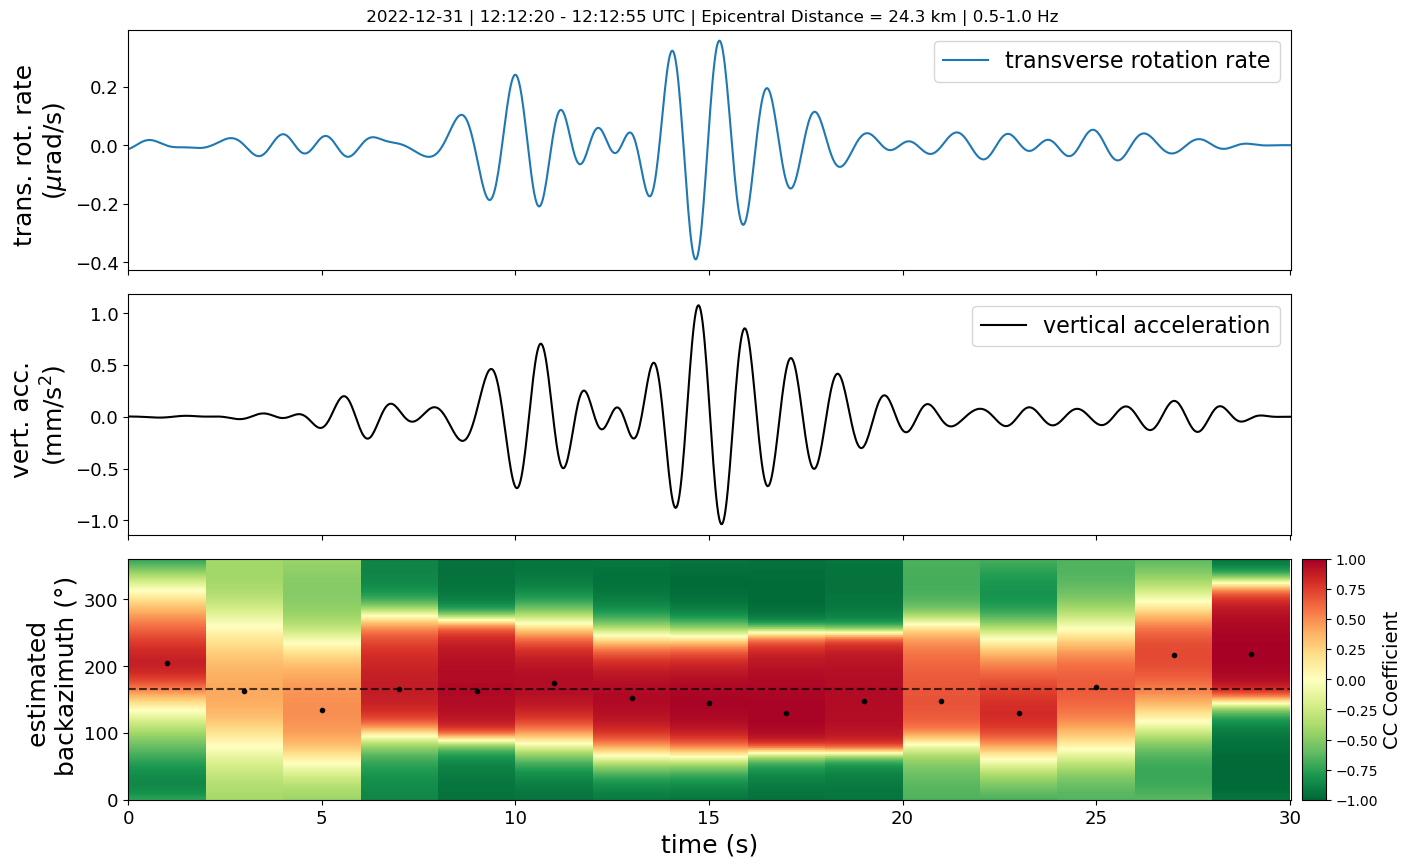

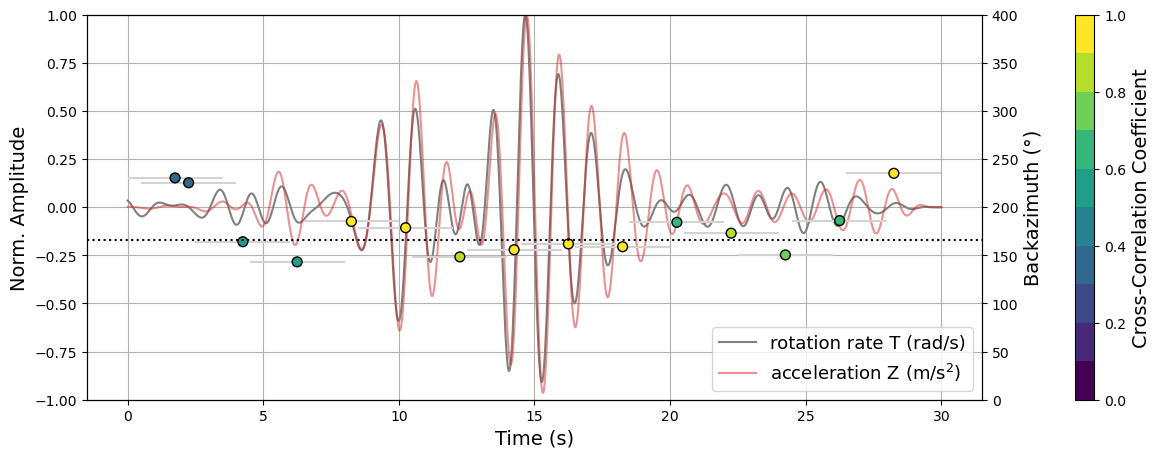

In [29]:
out1 = __compute_backazimuth(
                            acc,
                            rot,
                            config,
                            wave_type='love',
                            event=event,
                            plot=True,
                            flim=(fmin, fmax),
                            invert_rot_z=False,
                            show_details=False,
)

# out1['fig'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_love_{fmin}_{fmax}.png", dpi=150, bbox_inches='tight', pad_inches=0.05)


out2 = __compute_backazimuth(
                            acc,
                            rot,
                            config,
                            wave_type='rayleigh',
                            event=event,
                            plot=True,
                            flim=(fmin, fmax),
                            invert_acc_z=True,
                            show_details=False,
)

out2['fig'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_rayleigh_{fmin}_{fmax}.png", dpi=150, bbox_inches='tight', pad_inches=0.05)


out3 = __compute_backazimuth_tangent(
                                    rot,
                                    acc,
                                    win_time_s=config['win_length_sec'],
                                    overlap=config['overlap']/100,
                                    baz_theo=baz,
                                    cc_thres=0.1,
                                    plot=True,
                                    invert_acc_z=True,
                                    )

# out3['fig'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_tangent_{rot[0].stats.station}{fmin}_{fmax}.png", dpi=150, bbox_inches='tight', pad_inches=0.05)


In [30]:
def __compare_backazimuth_codes2(rot0, acc0, cat_event, fmin, fmax, Twin, Toverlap, cc_thres=None, invert_rot_z=False, invert_acc_z=False, plot=False):

    import scipy.stats as sts
    import matplotlib.pyplot as plt

    from numpy import ones, linspace, histogram, concatenate, average, argmax, isnan, sqrt, cov, nan, array, arange
    from obspy import UTCDateTime
    from obspy.signal.rotate import rotate_ne_rt
    from functions.compute_backazimuth import __compute_backazimuth
    from functions.compute_backazimuth_tangent import __compute_backazimuth_tangent

    rot = rot0.copy()
    acc = acc0.copy()

    rot.detrend("demean").taper(0.1).filter("bandpass", freqmin=fmin, freqmax=fmax)
    acc.detrend("demean").taper(0.1).filter("bandpass", freqmin=fmin, freqmax=fmax)

    config = {}

    config['tbeg'] = rot[0].stats.starttime
    config['tend'] = rot[0].stats.endtime

    ## Eventtime
    config['eventtime'] = UTCDateTime(cat_event.origins[0].time)

    ## specify coordinates of station
    config['station_longitude'] = -116.455439
    config['station_latitude'] = 33.6106

    ## specify window length for baz estimation in seconds
    config['win_length_sec'] = Twin

    ## define an overlap for the windows in percent (50 -> 50%)
    config['overlap'] = Toverlap

    ## specify steps for degrees of baz
    config['step'] = 1

    ## change polarization
    if invert_acc_z:
        acc.select(channel="*Z")[0].data *= -1
    if invert_rot_z:
        rot.select(channel="*Z")[0].data *= -1

    ## avoid double turn of polarization
    invert_acc_z = not invert_acc_z

    out1 = __compute_backazimuth(
                                acc,
                                rot,
                                config,
                                wave_type='rayleigh',
                                event=cat_event,
                                plot=False,
                                flim=(fmin, fmax),
                                show_details=False,
    )

    out2 = __compute_backazimuth(
                                acc,
                                rot,
                                config,
                                wave_type='love',
                                event=cat_event,
                                plot=False,
                                flim=(fmin, fmax),
                                show_details=False,
    )

    out3 = __compute_backazimuth_tangent(
                                        rot,
                                        acc,
                                        win_time_s= config['win_length_sec'],
                                        overlap=config['overlap']/100,
                                        baz_theo=out2['baz_theo'],
                                        cc_thres=0,
                                        plot=False,
                                        invert_acc_z=invert_acc_z,
    )

    ## filter according to cc-threshold
    if cc_thres:
        for ii, _cc in enumerate(out1['cc_max']):
            if abs(_cc) <= cc_thres:
                out1['cc_max'][ii], out1['cc_max_y'][ii] = nan, nan
        for ii, _cc in enumerate(out2['cc_max']):
            if abs(_cc) <= cc_thres:
                out2['cc_max'][ii], out2['cc_max_y'][ii] = nan, nan
        for ii, _cc in enumerate(out3['ccoef']):
            if abs(_cc) <= cc_thres:
                out3['ccoef'][ii], out3['baz_est'][ii] = nan, nan

    ## compute statistics
    deltaa = 10
    angles = arange(0, 365, deltaa)
    angles2 = arange(0, 365, 1)

    ## ______________________________________
    ## Rayleigh
    try:
        baz_rayleigh_no_nan = out1['cc_max_y'][~isnan(out1['cc_max_y'])]
        cc_rayleigh_no_nan = out1['cc_max'][~isnan(out1['cc_max'])]

        hist = histogram(out1['cc_max_y'], bins=len(angles)-1, range=[min(angles), max(angles)],
                         weights=out1['cc_max'], density=True)

        baz_rayleigh_mean = round(average(baz_rayleigh_no_nan, weights=cc_rayleigh_no_nan), 0)
        baz_rayleigh_std = sqrt(cov(baz_rayleigh_no_nan, aweights=cc_rayleigh_no_nan))

        # baz_rayleigh_max = angles[argmax(hist[0])]+deltaa  ## add half of deltaa to be in the bin center
        kde1 = sts.gaussian_kde(baz_rayleigh_no_nan, weights=baz_rayleigh_no_nan)
        baz_rayleigh_max = angles2[argmax(kde1.pdf(angles2))]

        ## ______________________________________
        ## Love
        baz_love_no_nan = out2['cc_max_y'][~isnan(out2['cc_max_y'])]
        cc_love_no_nan = out2['cc_max'][~isnan(out2['cc_max'])]

        hist = histogram(out2['cc_max_y'], bins=len(angles)-1, range=[min(angles), max(angles)],
                         weights=out2['cc_max'], density=True)

        baz_love_mean = round(average(baz_love_no_nan, weights=cc_love_no_nan), 0)
        baz_love_std = sqrt(cov(baz_love_no_nan, aweights=cc_love_no_nan))

        # baz_love_max = angles[argmax(hist[0])]+deltaa  ## add half of deltaa to be in the bin center
        kde2 = sts.gaussian_kde(baz_love_no_nan, weights=cc_love_no_nan)
        baz_love_max = angles2[argmax(kde2.pdf(angles2))]

        ## ______________________________________
        ## Tangent
        baz_tangent_no_nan = out3['baz_est'][~isnan(out3['ccoef'])]
        cc_tangent_no_nan = out3['baz_est'][~isnan(out3['ccoef'])]

        hist = histogram(out3['baz_est'], bins=len(angles)-1, range=[min(angles), max(angles)],
                         weights=out3['ccoef'], density=True)

        baz_tangent_mean = round(average(baz_tangent_no_nan, weights=cc_tangent_no_nan), 0)
        baz_tangent_std = sqrt(cov(baz_tangent_no_nan, aweights=cc_tangent_no_nan))

        # baz_tangent_max = angles[argmax(hist[0])]+deltaa  ## add half of deltaa to be in the bin center
        kde3 = sts.gaussian_kde(baz_tangent_no_nan, weights=cc_tangent_no_nan)
        baz_tangent_max = angles2[argmax(kde3.pdf(angles2))]

    except Exception as e:
        print(e)
        pass

    if plot:

        import matplotlib.pyplot as plt
        from matplotlib.gridspec import GridSpec

        Ncol, Nrow = 8, 5

        fig3 = plt.figure(figsize=(15, 10))

        gs = GridSpec(Nrow, Ncol, figure=fig3, hspace=0.15)

        ax0 = fig3.add_subplot(gs[0, :])
        ax1 = fig3.add_subplot(gs[1, :])
        # ax2 = fig3.add_subplot(gs[2, :])

        ax3 = fig3.add_subplot(gs[2, :])
        ax4 = fig3.add_subplot(gs[3, :])
        ax5 = fig3.add_subplot(gs[4, :])

        ax6 = fig3.add_subplot(gs[2, 7:])
        ax7 = fig3.add_subplot(gs[3, 7:])
        ax8 = fig3.add_subplot(gs[4, 7:])

        ax6.set_axis_off()
        ax7.set_axis_off()
        ax8.set_axis_off()

        for _ax in [ax0, ax1, ax3, ax4]:
            _ax.set_xticklabels([])

        rot_scaling, rot_unit = 1e6, r"$\mu$rad/s"
        trans_scaling, trans_unit = 1e3, r"mm/s$^2$"

        font = 12
        lw=1.0

        hz = acc.select(channel="*HZ")[0]
        hn = acc.select(channel="*HN")[0]
        he = acc.select(channel="*HE")[0]

        jz = rot.select(channel="*JZ")[0]
        jn = rot.select(channel="*JN")[0]
        je = rot.select(channel="*JE")[0]

        hr, ht = rotate_ne_rt(hn.data, he.data, out3['baz_theo'])
        jr, jt = rotate_ne_rt(jn.data, je.data, out3['baz_theo'])

        ## reverse polarity of transverse rotation!!
        # jt *= -1

        t1, t2 = hz.times().min(), hz.times().max()

        ax0.plot(hz.times(), (ht)*trans_scaling, 'black', label=f"PFO.T", lw=lw)
        ax1.plot(hz.times(), (hz.data)*trans_scaling, 'black', label=f"PFO.Z", lw=lw)
        # ax2.plot(hz.times(), hr*trans_scaling, 'black', label=f"PFO.R", lw=lw)

        ax0.set_ylim(-max(abs((ht)*trans_scaling)), max(abs((ht)*trans_scaling)))
        ax1.set_ylim(-max(abs((hz.data)*trans_scaling)), max(abs((hz.data)*trans_scaling)))
        # ax2.set_ylim(-max(abs(hr*trans_scaling)), max(abs(hr*trans_scaling)))

        ax00 = ax0.twinx()
        ax00.plot(jz.times(), jz.data*rot_scaling, 'darkred', label=r"BSPF.Z", lw=lw)

        ax11 = ax1.twinx()
        ax11.plot(jz.times(), jt*rot_scaling, 'darkred', label=r"BSPF.T", lw=lw)

        # ax22 = ax2.twinx()
        # ax22.plot(jz.times(), jt*rot_scaling, 'darkred', label=r"BSPF.T", lw=lw)

        ax00.set_ylim(-max(abs(jz.data*rot_scaling)), max(abs(jz.data*rot_scaling)))
        ax11.set_ylim(-max(abs(jt*rot_scaling)), max(abs(jt*rot_scaling)))
        # ax22.set_ylim(-max(abs(jt*rot_scaling)), max(abs(jt*rot_scaling)))

        cmap = plt.get_cmap("viridis", 10)

        ca3 = ax3.scatter(out1['cc_max_t'], out1['cc_max_y'], c=out1['cc_max'],
                          s=60, cmap=cmap, edgecolors="k", lw=1, vmin=0, vmax=1, zorder=2)
        ca4 = ax4.scatter(out2['cc_max_t'], out2['cc_max_y'], c=out2['cc_max'],
                          s=60, cmap=cmap, edgecolors="k", lw=1, vmin=0, vmax=1, zorder=2)
        ca5 = ax5.scatter(out3['t_win_center'], out3['baz_est'], c=out3['ccoef'], 
                        s=60, cmap=cmap, edgecolors="k", lw=1, vmin=0, vmax=1, zorder=2)

        cax3 = ax3.inset_axes([1.01, 0., 0.02, 1])
        cb3 = plt.colorbar(ca3, ax=ax3, cax=cax3)
        cb3.set_label("CC-Coeff.", fontsize=font)

        cax4 = ax4.inset_axes([1.01, 0., 0.02, 1])
        cb4 = plt.colorbar(ca4, ax=ax4, cax=cax4)
        cb4.set_label("CC-Coeff.", fontsize=font)

        cax5 = ax5.inset_axes([1.01, 0., 0.02, 1])
        cb5 = plt.colorbar(ca5, ax=ax5, cax=cax5)
        cb5.set_label("CC-Coeff.", fontsize=font)

        ax3.set_ylabel(f"Rayleigh Baz.(°)", fontsize=font)
        ax4.set_ylabel(f"Love Baz.(°)", fontsize=font)
        ax5.set_ylabel(f"CoVar. Baz.(°)", fontsize=font)

        ax66 = ax6.twinx()
        ax66.hist(out1['cc_max_y'], bins=len(angles)-1, range=[min(angles), max(angles)],
                  weights=out1['cc_max'], orientation="horizontal", density=True, color="grey")
        ax66.plot(kde1.pdf(angles), angles, c="k", lw=2, label='KDE')
        ax66.axhline(baz_rayleigh_max, color="k", ls="--")
        ax66.set_axis_off()
        ax66.yaxis.tick_right()
        ax66.invert_xaxis()

        ax77 = ax7.twinx()
        ax77.hist(out2['cc_max_y'], bins=len(angles)-1, range=[min(angles), max(angles)],
                  weights=out2['cc_max'], orientation="horizontal", density=True, color="grey")
        ax77.plot(kde2.pdf(angles), angles, c="k", lw=2, label='KDE')
        ax77.axhline(baz_love_max, color="k", ls="--")
        ax77.set_axis_off()
        ax77.yaxis.tick_right()
        ax77.invert_xaxis()

        ax88 = ax8.twinx()
        ax88.hist(out3['baz_est'], bins=len(angles)-1, range=[min(angles), max(angles)],
                  weights=out3['ccoef'], orientation="horizontal", density=True, color="grey")
        ax88.plot(kde3.pdf(angles), angles, c="k", lw=2, label='KDE')
        ax88.axhline(baz_tangent_max, color="k", ls="--")
        ax88.set_axis_off()
        ax88.yaxis.tick_right()
        ax88.invert_xaxis()


        ax0.set_yticks(linspace(ax0.get_yticks()[0], ax0.get_yticks()[-1], len(ax0.get_yticks())))
        ax00.set_yticks(linspace(ax00.get_yticks()[0], ax00.get_yticks()[-1], len(ax0.get_yticks())))

        ax1.set_yticks(linspace(ax1.get_yticks()[0], ax1.get_yticks()[-1], len(ax1.get_yticks())))
        ax11.set_yticks(linspace(ax11.get_yticks()[0], ax11.get_yticks()[-1], len(ax1.get_yticks())))

        # ax2.set_yticks(linspace(ax2.get_yticks()[0], ax2.get_yticks()[-1], len(ax2.get_yticks())))
        # ax22.set_yticks(linspace(ax22.get_yticks()[0], ax22.get_yticks()[-1], len(ax2.get_yticks())))

        for _ax in [ax0, ax1]:
            _ax.grid(which="both", ls=":", alpha=0.7, color="grey", zorder=0)
            _ax.legend(loc=1)
            _ax.set_ylabel(f"a ({trans_unit})", fontsize=font)
            _ax.set_xlim(0, (config['tend']-config['tbeg'])*1.15)

        for _ax in [ax3 ,ax4, ax5]:
            _ax.set_ylim(-5, 365)
            _ax.set_yticks(range(0, 360+60,60))
            _ax.grid(which="both", ls=":", alpha=0.7, color="grey", zorder=0)
            _ax.set_xlim(0,  (config['tend']-config['tbeg'])*1.15)

            _ax.plot([t1, t2], ones(2)*out3['baz_theo'], lw=1.5, alpha=0.7, color="k", ls="--", zorder=1)
            _ax.fill_between([t1, t2], ones(2)*out3['baz_theo']-10, ones(2)*out3['baz_theo']+10,
                             lw=1.5, alpha=0.5, color="grey", zorder=1)

        for aaxx in [ax00, ax11]:
            aaxx.tick_params(axis='y', colors="darkred")
            aaxx.set_ylabel(f"$\Omega$ ({rot_unit})", color="darkred", fontsize=font)
            aaxx.legend(loc=4)

        ax0.set_title(f" {config['tbeg'].date}  {str(config['tbeg'].time).split('.')[0]}-{str(config['tend'].time).split('.')[0]} UTC | f = {fmin}-{fmax} Hz | T = {config['win_length_sec']} s | {config['overlap']} % overlap")

        ax5.set_xlabel("Time (s)", fontsize=font)

        axes = [ax0, ax1, ax3, ax4, ax5]
        for _k, (ax, ll) in enumerate(zip(axes, ['(a)', '(b)', '(c)', '(d)', '(e)'])):
            ax.text(.005, .97, ll, ha='left', va='top', transform=ax.transAxes, fontsize=font+2)

        plt.show();

    ## prepare output directory
    out = {}
    out['baz_theo'] = round(out2['baz_theo'], 0)
    out['baz_angles'] = angles
    out['baz_tangent_max'] = baz_tangent_max
    out['baz_tangent_mean'] = baz_tangent_mean
    out['baz_tangent_std'] = baz_tangent_std
    out['baz_rayleigh_max'] = baz_rayleigh_max
    out['baz_rayleigh_mean'] = baz_rayleigh_mean
    out['baz_rayleigh_std'] = baz_rayleigh_std
    out['baz_love_max'] = baz_love_max
    out['baz_love_mean'] = baz_love_mean
    out['baz_love_std'] = baz_love_std

    if plot:
        # out['fig1'] = fig1
        # out['fig2'] = fig2
        out['fig3'] = fig3

    return out

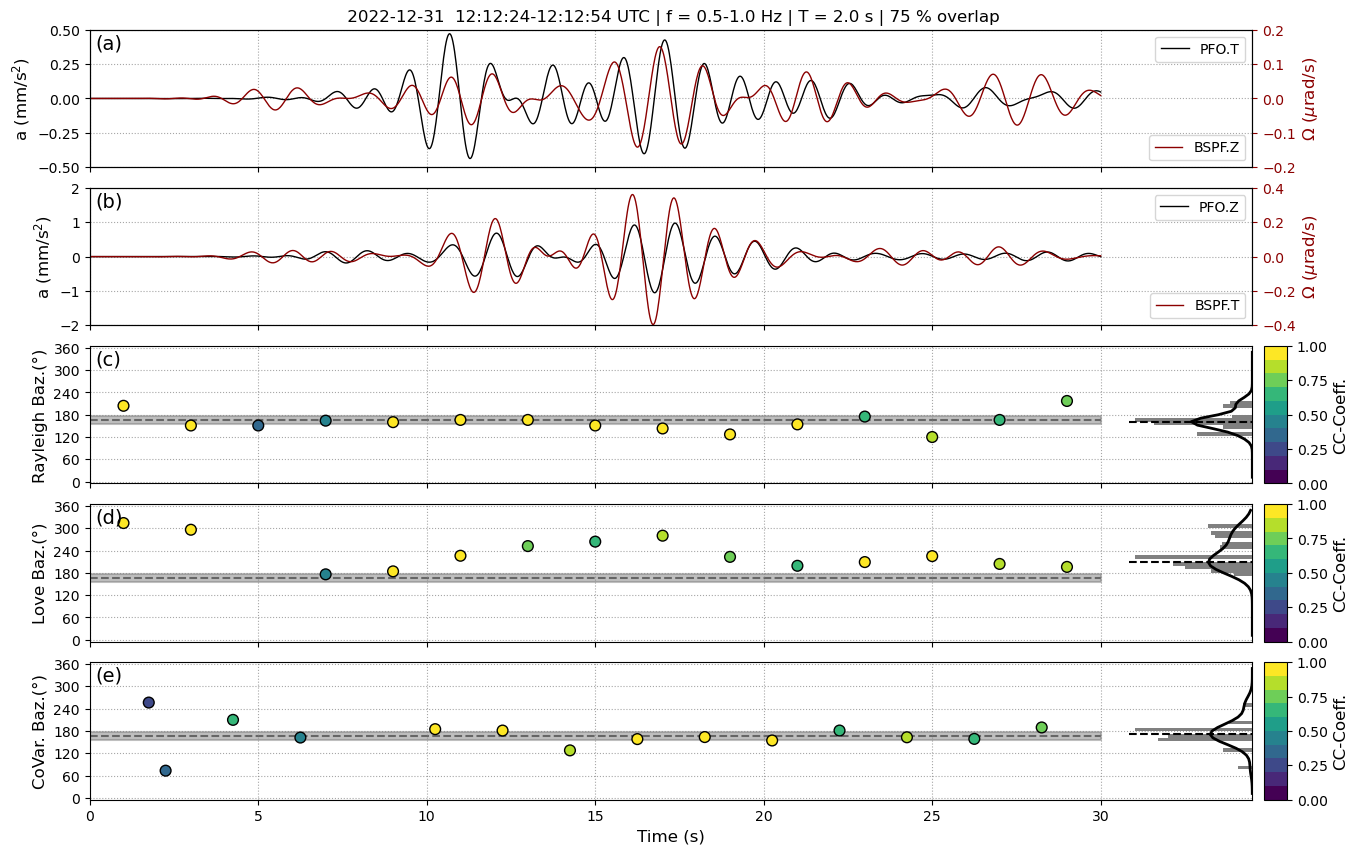

In [31]:
out4 = __compare_backazimuth_codes2(rot, acc, event,
                                   fmin, fmax,
                                   config['win_length_sec'],
                                   config['overlap'],
                                   cc_thres=0.2,
                                   invert_acc_z=True,
                                   plot=True
                                  );

out4['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_{fmin}_{fmax}_all.png", dpi=150, bbox_inches='tight', pad_inches=0.05);


### Compare Backazimuth Estimate for ADR, BSPF and Beamforming

In [32]:
from functions.compute_beamforming_pfo import __compute_beamforming_pfo

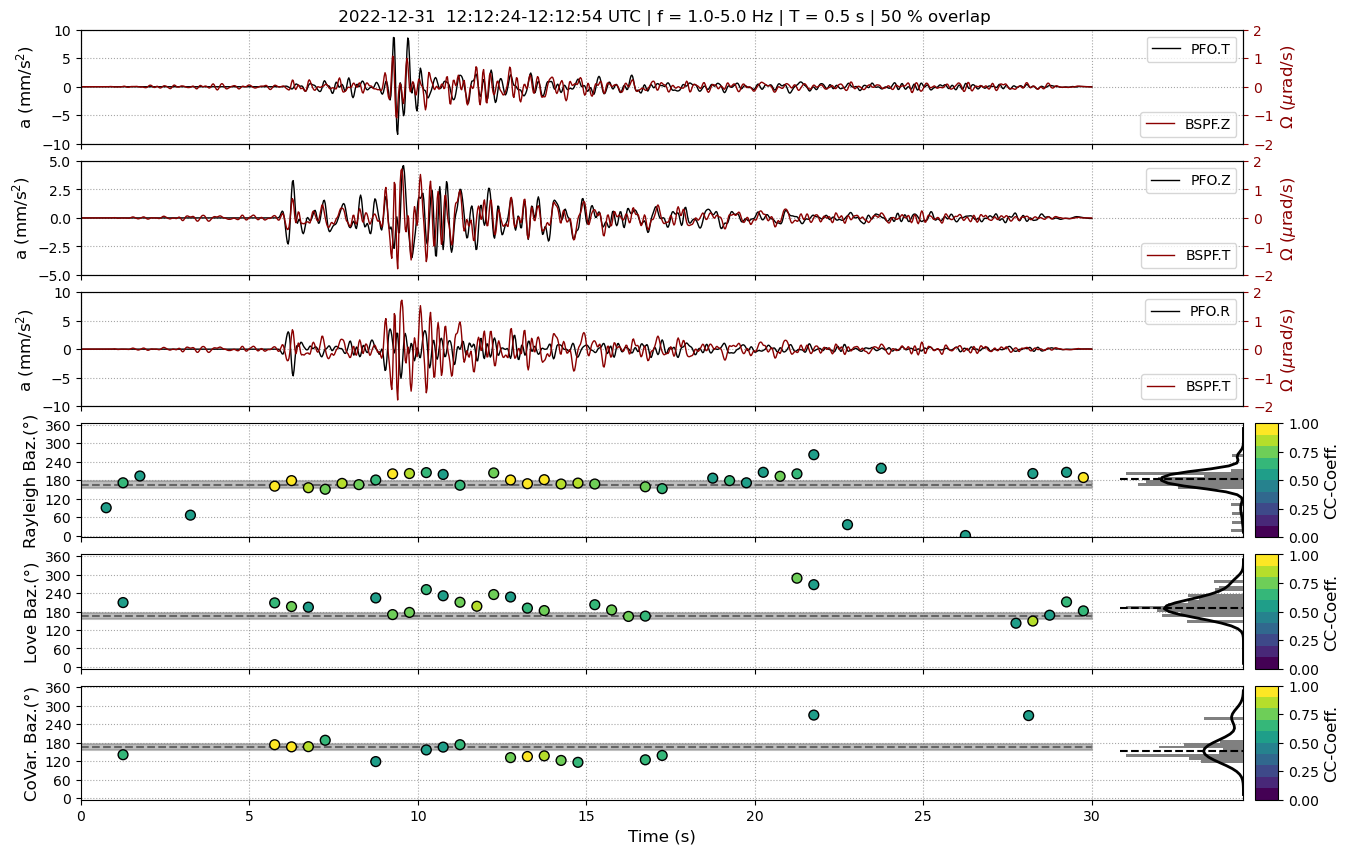

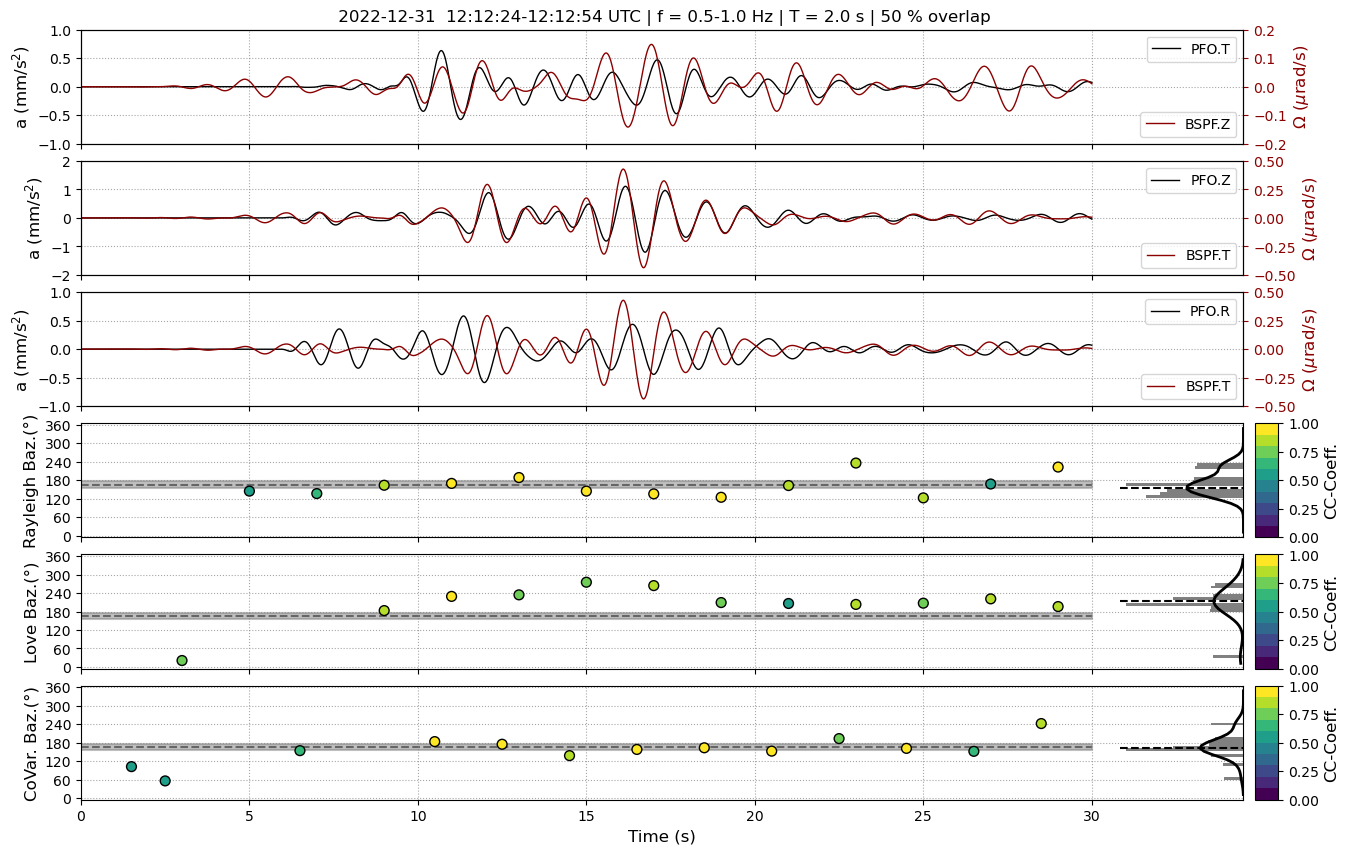

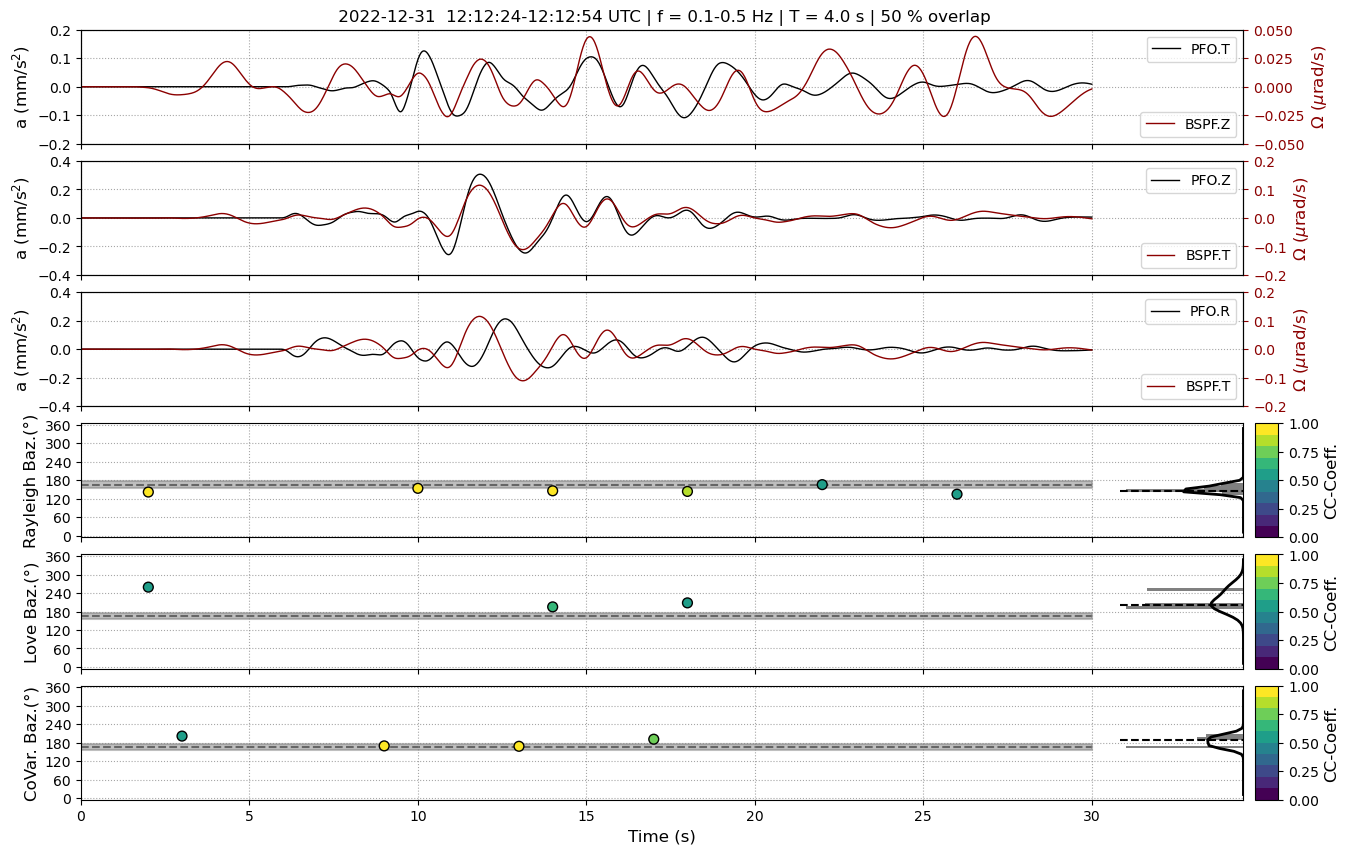

 -> obtained: 5 of 5 stations!

 -> Runtime: 0.99 minutes
 -> obtained: 8 of 8 stations!

 -> Runtime: 1.7 minutes
 -> obtained: 13 of 13 stations!

 -> Runtime: 2.69 minutes


In [33]:
stt = st0.copy();

acc0 = stt.copy().select(station="PFO*");
rot0 = stt.copy().select(station="BSPF");

# for tr in acc0:
#     if "Z" in tr.stats.channel:
#         tr.data *= -1

cc_thres = 0.5

Twin_factor = 1

Twin_overlap = 50

## direct rotation
out_bspf_i = __compare_backazimuth_codes(rot0, acc0, event, 1.0, 5.0, Twin_factor/2.0, Twin_overlap,
                                         cc_thres=cc_thres, invert_acc_z=True, plot=True);
out_bspf_i['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_2.0_5.0_all.png",
                           dpi=200, bbox_inches='tight', pad_inches=0.05);

out_bspf_m = __compare_backazimuth_codes(rot0, acc0, event, 0.5, 1.0, Twin_factor/0.5, Twin_overlap,
                                         cc_thres=cc_thres, invert_acc_z=True, plot=True);
out_bspf_m['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_0.5_1.0_all.png",
                           dpi=200, bbox_inches='tight', pad_inches=0.05);

out_bspf_a = __compare_backazimuth_codes(rot0, acc0, event, 0.1, 0.5, Twin_factor/0.25, Twin_overlap,
                                         cc_thres=cc_thres, invert_acc_z=True, plot=True);
out_bspf_a['fig3'].savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_{rot[0].stats.location}_0.1_0.5_all.png",
                           dpi=200, bbox_inches='tight', pad_inches=0.05);


## adr rotation
rot1 = stt.copy().select(station="RPFO", location="in");
out_adr_i = __compare_backazimuth_codes(rot1, acc0, event, 1.0, 5.0, Twin_factor/2.0, Twin_overlap,
                                        cc_thres=cc_thres, invert_acc_z=True, plot=False);

rot2 = stt.copy().select(station="RPFO", location="mi");
out_adr_m = __compare_backazimuth_codes(rot2, acc0, event, 0.5, 1.0, Twin_factor/0.5, Twin_overlap,
                                        cc_thres=cc_thres, invert_acc_z=True, plot=False);

rot3 = stt.copy().select(station="RPFO", location="al");
out_adr_a = __compare_backazimuth_codes(rot3, acc0, event, 0.1, 0.5, Twin_factor/0.25, Twin_overlap,
                                        cc_thres=cc_thres, invert_acc_z=True, plot=False);

## array beamforming
out_bf_i = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=1.0, fmax=5.0,
                                     component="Z", submask="inner", plot=False)
out_bf_m = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=0.5, fmax=1.0,
                                     component="Z", submask="mid", plot=False)
out_bf_a = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=0.1, fmax=0.5,
                                     component="Z", submask="all", plot=False)
# out_bf_o = __compute_beamforming_pfo(config['tbeg'], config['tend'], fmin=0.8, fmax=1.0,
#                                      component="Z", submask="mid", plot=False)


In [34]:
def __makeplot_comparison():

    labels = ["iBSPF", "iADR", "iBF", "mBSPF", "mADR", "mBF", "aBSPF", "aADR", "aBF"]

    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    font = 16

    ax.axhline(out_bspf_i['baz_theo'], color="k", ls="--", label="theo. Baz.")
    ax.fill_between([-0.3, 4.0], out_bspf_i['baz_theo']-10, out_bspf_i['baz_theo']+10, color="grey", alpha=0.5, label="theo. Baz. +- 10°")


    for j, out in enumerate([out_adr_i, out_adr_m, out_adr_a]):

        ax.errorbar(j-0.02, out['baz_tangent_max'], yerr=out['baz_tangent_std'], color="tab:blue", zorder=2)
        ax.errorbar(j, out['baz_love_max'], yerr=out['baz_love_std'], color="tab:green", zorder=2)
        ax.errorbar(j+0.02, out['baz_rayleigh_max'], yerr=out['baz_rayleigh_std'], color="tab:red", zorder=2)

        ax.scatter(j-0.02, out['baz_tangent_max'], color="tab:blue", zorder=2, label="Co.Var.", edgecolors="k")
        ax.scatter(j, out['baz_love_max'], color="tab:green", zorder=2, label="Love", edgecolors="k")
        ax.scatter(j+0.02, out['baz_rayleigh_max'], color="tab:red", zorder=2, label="Rayleigh", edgecolors="k")

        ## plot only for legend icon

        if j == 0:
            ax.scatter(j+0.4, out_bf_i['baz_bf_max'], color="tab:orange", zorder=2, label="beamforming", edgecolors="k")
            ax.legend(loc=1, fontsize=font-3)


    for j, out in enumerate([out_bspf_i, out_bspf_m, out_bspf_a]):

        ax.errorbar(j+0.18, out['baz_tangent_max'], yerr=out['baz_tangent_std'], color="tab:blue", zorder=2)
        ax.errorbar(j+0.2, out['baz_love_max'], yerr=out['baz_love_std'], color="tab:green", zorder=2)
        ax.errorbar(j+0.22, out['baz_rayleigh_max'], yerr=out['baz_rayleigh_std'], color="tab:red", zorder=2)

        ax.scatter(j+0.18, out['baz_tangent_max'], color="tab:blue", zorder=2, label="Co.Var.", edgecolors="k")
        ax.scatter(j+0.2, out['baz_love_max'], color="tab:green", zorder=2, label="Love", edgecolors="k")
        ax.scatter(j+0.22, out['baz_rayleigh_max'], color="tab:red", zorder=2, label="Rayleigh", edgecolors="k")


    for j, out in enumerate([out_bf_i, out_bf_m, out_bf_a]):

        ax.errorbar(j+0.4, out['baz_bf_max'], yerr=out['baz_bf_std'], color="tab:orange", zorder=2)
        ax.scatter(j+0.4, out['baz_bf_max'], color="tab:orange", zorder=2, label="", edgecolors="k")



    ax.set_xticks([0,0.2,0.4,1,1.2,1.4,2,2.2,2.4], labels=labels, fontsize=font-1)

    ax.grid(axis="y", ls=":", color="k", alpha=0.5, zorder=0)

    ax.text(0, 360+10, "1.0 - 5.0 Hz", fontsize=font-1)
    ax.text(1, 360+10, "0.5 - 1.0 Hz", fontsize=font-1)
    ax.text(2, 360+10, "0.1 - 0.5 Hz", fontsize=font-1)
    # ax.text(3, 360+10, "0.8 - 1.0 Hz", fontsize=font-1)

    ax.xaxis.label.set_size(font-1)
    ax.yaxis.label.set_size(font-1)

    ax.set_ylim(-5, 365)
    ax.set_yticks(range(0, 360+60,60))

    ax.set_ylabel("Backazimuth (°)", fontsize=font)

    ax.set_xlim(-0.3, 3.0)
    ax.set_ylim(0, 360)

    plt.show();
    return fig

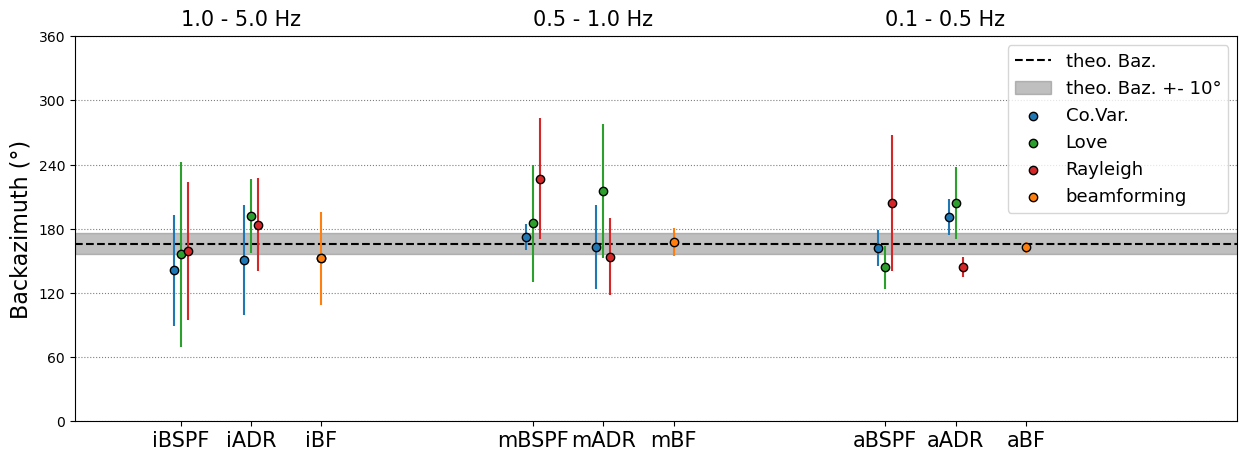

In [35]:
fig = __makeplot_comparison()

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_baz_comparison_overview.png", dpi=200, bbox_inches='tight', pad_inches=0.05);


## Phase Velocity

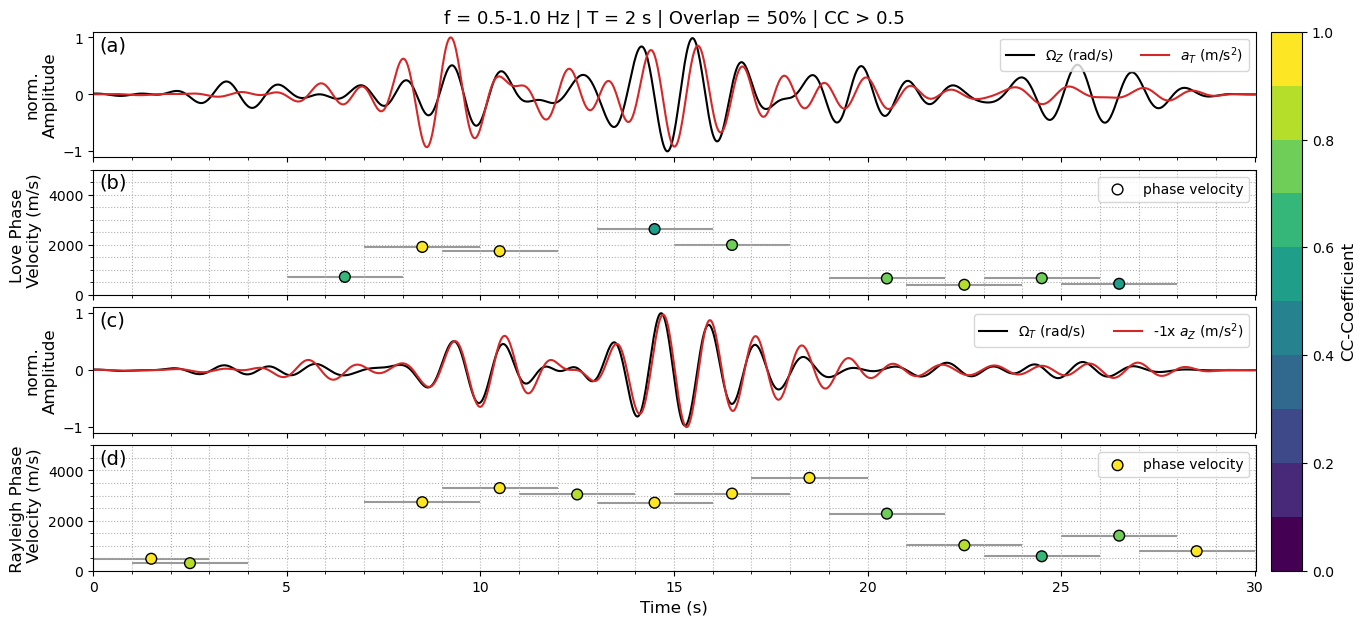

In [36]:
fig = __makeplot_velocities(rot, acc, fmin, fmax, baz,
                            twin=2, overlap=0.5, cc_threshold=0.5,
                            reverse_rotZ=False, reverse_accZ=True,
                            vmax=5000,
                            );

fig.savefig(config['path_to_figs']+f"BSPF_{config['name']}_velocities_{rot[0].stats.station}_{fmin}_{fmax}.png", dpi=200, bbox_inches='tight', pad_inches=0.05)
